# Task 4: Обнаружение мошенничества (Fraud Detection)
В финансовых данных транзакции-фрод встречаются очень редко (imbalanced data). Мы сгенерируем синтетический датасет, имитирующий эту проблему, и применим Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

In [2]:
# Генерация несбалансированного датасета (10 000 транзакций, только 1% - фрод)
X, y = make_classification(n_samples=10000, n_features=10, n_informative=4, 
                           n_redundant=1, weights=[0.99, 0.01], 
                           flip_y=0, random_state=42)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(10)])
df['is_fraud'] = y

print("Распределение классов (0 - легальные, 1 - фрод):")
print(df['is_fraud'].value_counts())

Распределение классов (0 - легальные, 1 - фрод):
is_fraud
0    9900
1     100
Name: count, dtype: int64


In [3]:
# Обучение модели
X_train, X_test, y_train, y_test = train_test_split(df.drop('is_fraud', axis=1), df['is_fraud'], test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1984
           1       1.00      0.38      0.55        16

    accuracy                           0.99      2000
   macro avg       1.00      0.69      0.77      2000
weighted avg       1.00      0.99      0.99      2000



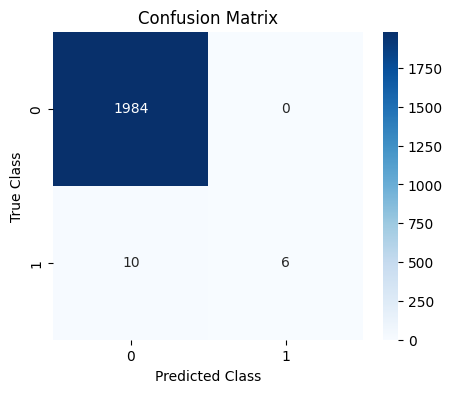

In [4]:
# Оценка результатов
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()